In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from collections import Counter

## Cargar dataset

Descarga el dataset desde Kaggle:
👉 https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Luego, cárgalo (suponiendo que está en el mismo directorio):

In [14]:
df = pd.read_csv("C:\\Users\\manue\\OneDrive\\Documentos\\Ulatina\\Git\\creditcard.csv")
print(df.head())
print(df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## Visualizar desbalance original

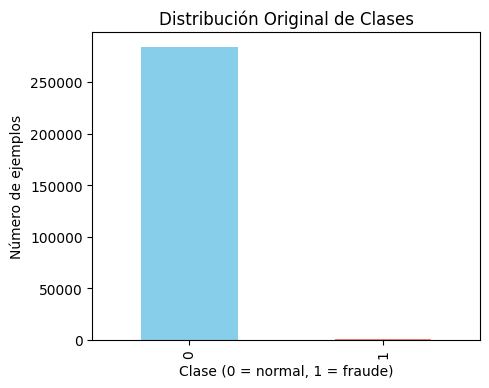

In [15]:
plt.figure(figsize=(5,4))
df['Class'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Distribución Original de Clases')
plt.xlabel('Clase (0 = normal, 1 = fraude)')
plt.ylabel('Número de ejemplos')
plt.show()

## Separar variables y objetivo

In [16]:
X = df.drop('Class', axis=1)
y = df['Class']

## Método 1: Undersampling

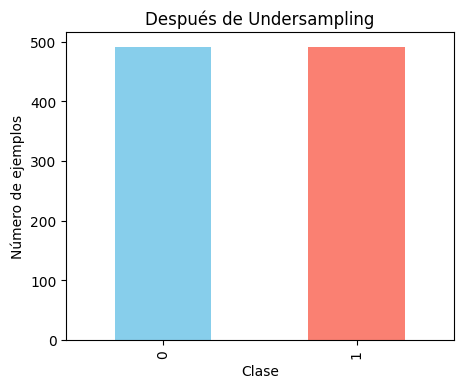

In [17]:
undersampler = RandomUnderSampler(random_state=42)
X_under, y_under = undersampler.fit_resample(X, y)

plt.figure(figsize=(5,4))
pd.Series(y_under).value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Después de Undersampling')
plt.xlabel('Clase')
plt.ylabel('Número de ejemplos')
plt.show()

## Método 2: Oversampling

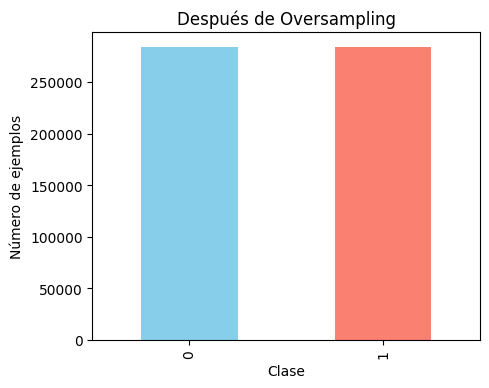

In [18]:
oversampler = RandomOverSampler(random_state=42)
X_over, y_over = oversampler.fit_resample(X, y)

plt.figure(figsize=(5,4))
pd.Series(y_over).value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Después de Oversampling')
plt.xlabel('Clase')
plt.ylabel('Número de ejemplos')
plt.show()


## Método 3: SMOTE (Synthetic Minority Oversampling Technique)

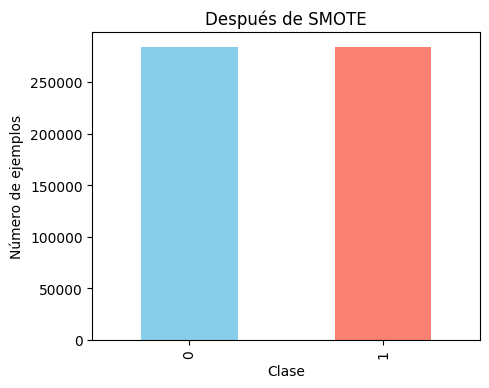

In [19]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X, y)

plt.figure(figsize=(5,4))
pd.Series(y_smote).value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Después de SMOTE')
plt.xlabel('Clase')
plt.ylabel('Número de ejemplos')
plt.show()

## Comparación de tamaños finales

In [20]:
print("Tamaño original:", Counter(y))
print("Tamaño undersampling:", Counter(y_under))
print("Tamaño oversampling:", Counter(y_over))
print("Tamaño SMOTE:", Counter(y_smote))

Tamaño original: Counter({0: 284315, 1: 492})
Tamaño undersampling: Counter({0: 492, 1: 492})
Tamaño oversampling: Counter({0: 284315, 1: 284315})
Tamaño SMOTE: Counter({0: 284315, 1: 284315})


## Prueva con RF
---
### Dividir la data 

In [21]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2

# Original
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# Undersampled
X_train_under, X_test_under, y_train_under, y_test_under = train_test_split(
    X_under, y_under, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_under)

# Oversampled
X_train_over, X_test_over, y_train_over, y_test_over = train_test_split(
    X_over, y_over, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_over)

# SMOTE
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_smote, y_smote, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_smote)

# Resumen de tamaños y distribuciones
print("Original: X_train:", X_train_orig.shape, "X_test:", X_test_orig.shape)
print("  y_train:", Counter(y_train_orig), " y_test:", Counter(y_test_orig))
print("Undersampled: X_train:", X_train_under.shape, "X_test:", X_test_under.shape)
print("  y_train:", Counter(y_train_under), " y_test:", Counter(y_test_under))
print("Oversampled: X_train:", X_train_over.shape, "X_test:", X_test_over.shape)
print("  y_train:", Counter(y_train_over), " y_test:", Counter(y_test_over))
print("SMOTE: X_train:", X_train_smote.shape, "X_test:", X_test_smote.shape)
print("  y_train:", Counter(y_train_smote), " y_test:", Counter(y_test_smote))

Original: X_train: (227845, 30) X_test: (56962, 30)
  y_train: Counter({0: 227451, 1: 394})  y_test: Counter({0: 56864, 1: 98})
Undersampled: X_train: (787, 30) X_test: (197, 30)
  y_train: Counter({1: 394, 0: 393})  y_test: Counter({0: 99, 1: 98})
Oversampled: X_train: (454904, 30) X_test: (113726, 30)
  y_train: Counter({0: 227452, 1: 227452})  y_test: Counter({1: 56863, 0: 56863})
SMOTE: X_train: (454904, 30) X_test: (113726, 30)
  y_train: Counter({0: 227452, 1: 227452})  y_test: Counter({1: 56863, 0: 56863})


### Entrenar y provar RF


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd

# Entrenar 4 Random Forest (Original / Undersampling / Oversampling / SMOTE)
# Usar los splits ya definidos en celdas anteriores:
# X_train_orig, X_test_orig, y_train_orig, y_test_orig, 
# X_train_under, X_test_under, y_train_under, y_test_under,
# X_train_over, X_test_over, y_train_over, y_test_over,
# X_train_smote, X_test_smote, y_train_smote, y_test_smote


RANDOM_STATE = 42

def train_and_eval(name, X_tr, y_tr, X_te, y_te):
    clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    # ROC AUC solo si hay ambos labels en y_te
    try:
        if len(np.unique(y_te)) > 1:
            y_proba = clf.predict_proba(X_te)[:, 1]
            roc = roc_auc_score(y_te, y_proba)
        else:
            roc = np.nan
    except Exception:
        roc = np.nan
    return {
        "dataset": name,
        "n_train": X_tr.shape[0],
        "n_test": X_te.shape[0],
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc,
        "tn": int(confusion_matrix(y_te, y_pred).ravel()[0]) if confusion_matrix(y_te, y_pred).size==4 else np.nan,
        "fp": int(confusion_matrix(y_te, y_pred).ravel()[1]) if confusion_matrix(y_te, y_pred).size==4 else np.nan,
        "fn": int(confusion_matrix(y_te, y_pred).ravel()[2]) if confusion_matrix(y_te, y_pred).size==4 else np.nan,
        "tp": int(confusion_matrix(y_te, y_pred).ravel()[3]) if confusion_matrix(y_te, y_pred).size==4 else np.nan
    }

results = []
results.append(train_and_eval("Original", X_train_orig, y_train_orig, X_test_orig, y_test_orig))
results.append(train_and_eval("Undersampling", X_train_under, y_train_under, X_test_under, y_test_under))
results.append(train_and_eval("Oversampling", X_train_over, y_train_over, X_test_over, y_test_over))
results.append(train_and_eval("SMOTE", X_train_smote, y_train_smote, X_test_smote, y_test_smote))

results_df = pd.DataFrame(results).set_index("dataset")
# Ordenar por métrica relevante (por ejemplo f1)
results_df = results_df.sort_values(by="f1", ascending=False)

print("Resumen de métricas (ordenado por F1):")
display(results_df)

# Veredicto simple: mejor por F1 y por ROC_AUC (si disponible)
best_by_f1 = results_df["f1"].idxmax()
best_by_roc = results_df["roc_auc"].idxmax() if results_df["roc_auc"].notna().any() else None

print("\nVeredicto:")
print(f"- Mejor según F1: {best_by_f1}")
if best_by_roc:
    print(f"- Mejor según ROC AUC: {best_by_roc}")
else:
    print("- ROC AUC no disponible para comparación en todos los conjuntos.")

Resumen de métricas (ordenado por F1):


,n_train,n_test,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
dataset,,,,,,,,,,,
Oversampling,454904,113726,0.999956,0.999912,1.000000,0.999956,1.000000,56858,5,0,56863
SMOTE,454904,113726,0.999842,0.999701,0.999982,0.999842,0.999999,56846,17,1,56862
Undersampling,787,197,0.954315,0.968421,0.938776,0.953368,0.990105,96,3,6,92
Original,227845,56962,0.999596,0.941176,0.816327,0.874317,0.963027,56859,5,18,80



Veredicto:
- Mejor según F1: Oversampling
- Mejor según ROC AUC: Oversampling
